## Bike Station Popularity using Radom Forest Classifier (machine learning model)

https://oslobysykkel.no/apne-data/historiskLinks to an external site.
Using the Oslo Bysykkel dataset, this creates a machine learning algorithm that predicts whether a bike station is High, Medium, or Low popularity based on usage patterns.





Details:
Input features: Station location, total trips started from station, total trips ended at station, average trip duration, day of week patterns
Example output: Popularity category (High/Medium/Low usage)
Data file: Bysykkel_09.csv (September 2025 data with about 138,000 trip records)

Steps:
1. Data processing: Groups trips by station id and calculate total metrics for each station (feel free to use a small subset of the stations to simplify the processing if needed). 
<br>

2. 
Features: total_trips_started, total_trips_ended, avg_duration.
target variable: Calculate total station usage (trips ended + trips started). 



At the end shows confusion matrix and prediction accuracy score.

# 1. Data processing


In [84]:
# Group trips by station id and calculate total metrics for each station (feel free to use a small subset of the stations to simplify the processing if needed). 

# Features: station id, started_at, duration.
import pandas as pd
df = pd.read_csv("09.csv") # Load the dataset

df.info() # Get a summary/information of the dataframe. Check column names and data types. Prints but does not return a value.

print(df.head()) # View the first few rows. Creates a new dataframe but does not modify df. Does not print or returan a value









<class 'pandas.core.frame.DataFrame'>
RangeIndex: 138416 entries, 0 to 138415
Data columns (total 13 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   started_at                 138416 non-null  object 
 1   ended_at                   138416 non-null  object 
 2   duration                   138416 non-null  int64  
 3   start_station_id           138416 non-null  int64  
 4   start_station_name         138416 non-null  object 
 5   start_station_description  138416 non-null  object 
 6   start_station_latitude     138416 non-null  float64
 7   start_station_longitude    138416 non-null  float64
 8   end_station_id             138416 non-null  int64  
 9   end_station_name           138416 non-null  object 
 10  end_station_description    138416 non-null  object 
 11  end_station_latitude       138416 non-null  float64
 12  end_station_longitude      138416 non-null  float64
dtypes: float64(4), int64(3), obje

In [85]:
# Total trips started
total_trips_started = df.groupby('start_station_id').size().reset_index(name='total_trips_started')

# Total trips ended
total_trips_ended = df.groupby('end_station_id').size().reset_index(name='total_trips_ended')

# Average trip duration (for trips starting at the station)
avg_duration = df.groupby('start_station_id')['duration'].mean().reset_index(name='avg_duration')



# Merge trips_started and trips_ended
station_metrics = pd.merge(total_trips_started, total_trips_ended, left_on='start_station_id', right_on='end_station_id', how='outer')

# Merge with avg_duration
station_metrics = pd.merge(station_metrics, avg_duration, left_on='start_station_id', right_on='start_station_id', how='outer')

# Rename columns for clarity
station_metrics.rename(columns={'start_station_id': 'station_id'}, inplace=True)

station_metrics.fillna(0, inplace=True) # Fill NaN values with 0 and inplace means don't create a copy but modify the existing one.

station_metrics.head()


,station_id,total_trips_started,end_station_id,total_trips_ended,avg_duration
0,377,337,377,297,710.513353
1,380,1103,380,463,748.097915
2,381,607,381,691,734.202636
3,382,313,382,294,679.910543
4,383,880,383,391,651.603409


In [86]:
station_metrics['total_station_usage'] = station_metrics['total_trips_ended'] + station_metrics['total_trips_started'] # new column that is the sum of two other columns

station_metrics['usage_category'] = pd.qcut(
    station_metrics['total_station_usage'], 
    q=3, # Divides into 3 quantiles
    labels=['low', 'Medium', 'High'] # "Low", "Medium", "High" categories of popilarity
)
print(station_metrics[['station_id', 'total_station_usage', 'usage_category']].head())


print(station_metrics['usage_category'].value_counts()) # Count of stations in each category

station_metrics.head()


   station_id  total_station_usage usage_category
0         377                  634            low
1         380                 1566           High
2         381                 1298           High
3         382                  607            low
4         383                 1271           High
low       89
Medium    89
High      89
Name: usage_category, dtype: int64


,station_id,total_trips_started,end_station_id,total_trips_ended,avg_duration,total_station_usage,usage_category
0,377,337,377,297,710.513353,634,low
1,380,1103,380,463,748.097915,1566,High
2,381,607,381,691,734.202636,1298,High
3,382,313,382,294,679.910543,607,low
4,383,880,383,391,651.603409,1271,High


## 2. ML model training and evaluation results

Accuracy: 0.93


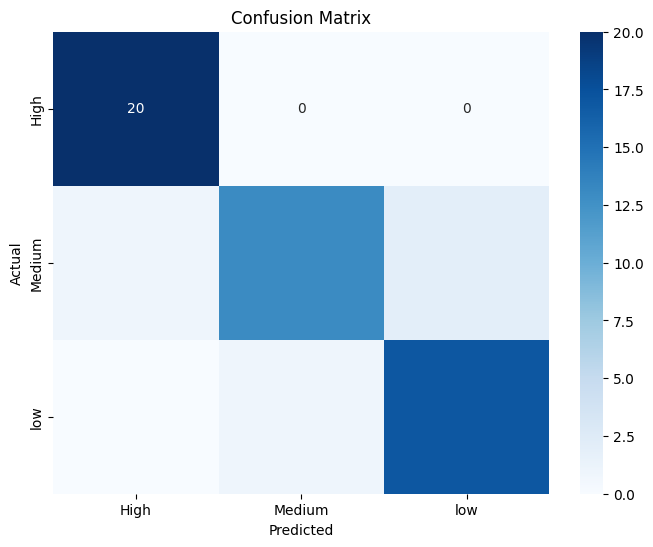

              precision    recall  f1-score   support

        High       0.95      1.00      0.98        20
      Medium       0.93      0.81      0.87        16
         low       0.89      0.94      0.92        18

    accuracy                           0.93        54
   macro avg       0.93      0.92      0.92        54
weighted avg       0.93      0.93      0.92        54



In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder

# Encode the target variable
le = LabelEncoder()
station_metrics['usage_category_encoded'] = le.fit_transform(station_metrics['usage_category'])



# Define features (X) and target (y)
X = station_metrics[['total_trips_started', 'total_trips_ended', 'avg_duration']]  # Features
y = station_metrics['usage_category_encoded']  # Target

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# Initialize and train the model
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)


# Make predictions
y_pred = model.predict(X_test)




accuracy = accuracy_score(y_test, y_pred)    # Accuracy = TP + TN / TP + TN + FP + FN
print(f"Accuracy: {accuracy:.2f}")


# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()



print(classification_report(y_test, y_pred, target_names=le.classes_))


